In [2]:
from classiq import *
from classiq import ExecutionSession
import numpy as np
import math

In [6]:
# Input parameters 

# Evolve the state over some time period
start = 0.0
stop  = 1.0
step  = 20
times = np.linspace(start, stop, step)
k = 4

num_ancilla = math.ceil(math.log(k + 1, 2)) # determine ancilla size from k
num_of_probs= 2**num_ancilla
probs= 1/num_of_probs
placeholder= [probs]*num_of_probs


# Main function
@qfunc
def main(work_q: Output[QBit], anc_q: Output[QArray[QBit]], t: CReal):
    allocate(1, work_q) # allocate work qubits
    allocate(num_ancilla, anc_q) # allocate ancilla qubits
    
    H(work_q) # prepare superposition

    inplace_prepare_state( probabilities=placeholder, bound=0.005, target=anc_q) # Prepare ancilla states

    for m in range(num_ancilla):

        # Map cyclic behavior of M^m
        mod_class = m % 4

        if mod_class == 0:
            # Identity... do nothing
            pass

        elif mod_class == 1:
            control(
                anc_q[m],
                lambda: Y(work_q)
            )

        elif mod_class == 2:
            control(
                anc_q[m],
                lambda: Z(work_q)
            )

        elif mod_class == 3:
            control(
                anc_q[m],
                lambda: Y(work_q)
            )

    invert(lambda: inplace_prepare_state(probabilities= placeholder, bound=0.005, target=anc_q)) # Decode ancilla states

# Synthesize once with placeholder values
qprog = synthesize(main)

# Function to use Taylor coefficients for ancilla state preparation
def build_params_for_t(t_val: float):
    amps = np.array([ (t_val**m) / math.factorial(m) for m in range(k+1) ]) # Taylor coefficients using t^m / m!
    amps = amps / np.linalg.norm(amps) # Normalize

    return {
        "t": float(t_val),
        "probabilities": amps.tolist(), #override placeholder t values 
        "k": k  # can change bound to work on optimization
    }
params_list = [build_params_for_t(t) for t in times]
# Execute batch with overrides
with ExecutionSession(qprog) as session:
    batch_results = session.batch_sample(params_list)

# Circuit visualization
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3AQxtbZKDDXnc4CzbqQxXZk4D9E


In [3]:
parsed_list = [dict(res)['parsed_states'] for res in batch_results]

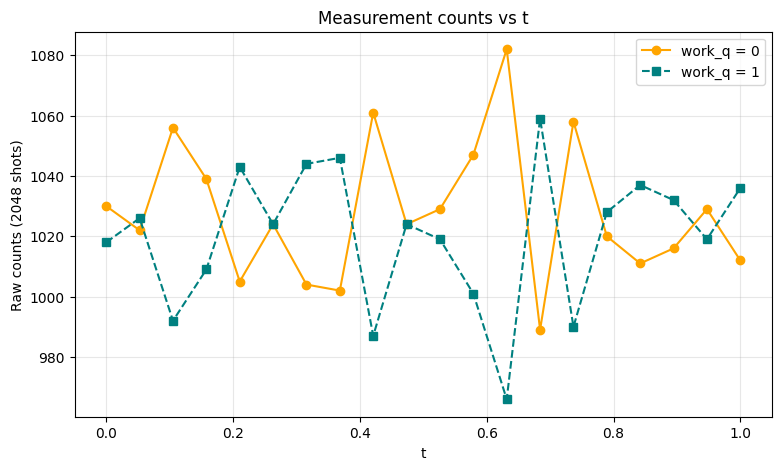

In [4]:
import matplotlib.pyplot as plt

counts_0 = []
counts_1 = []

for res in batch_results:
    d = dict(res)
    counts = d['counts']
    parsed = d['parsed_states']
    
    c0 = sum(cnt for st, cnt in counts.items() if parsed[st]['work_q'] == 0)
    c1 = sum(cnt for st, cnt in counts.items() if parsed[st]['work_q'] == 1)
    
    counts_0.append(c0)
    counts_1.append(c1)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(times, counts_0, 'o-', label='work_q = 0', color='orange')
plt.plot(times, counts_1, 's--', label='work_q = 1', color='teal')
plt.xlabel('t')
plt.ylabel('Raw counts (2048 shots)')
plt.title('Measurement counts vs t')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()